In [170]:
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
import numpy as np

In [171]:
data=pd.read_csv(r"C:\Users\kumar\Downloads\Housing (1).csv")

In [172]:
df=data.copy()

In [173]:
df["mainroad1"]=df["mainroad"].apply(lambda x:1 if x=="yes" else 0)

In [174]:
df["guestroom1"]=df["guestroom"].apply(lambda x:1 if x=="yes" else 0)
df["basement1"]=df["basement"].apply(lambda x:1 if x=="yes" else 0)
df["hotwaterheating1"]=df["hotwaterheating"].apply(lambda x:1 if x=="yes" else 0)
df["airconditioning1"]=df["airconditioning"].apply(lambda x:1 if x=="yes" else 0)
df["prefarea1"]=df["prefarea"].apply(lambda x:1 if x=="yes" else 0)

In [175]:
data["furnishingstatus"].unique()

array(['furnished', 'semi-furnished', 'unfurnished'], dtype=object)

In [176]:
df["furnishingstatus"].value_counts(),data["furnishingstatus"].value_counts()

(furnishingstatus
 semi-furnished    227
 unfurnished       178
 furnished         140
 Name: count, dtype: int64,
 furnishingstatus
 semi-furnished    227
 unfurnished       178
 furnished         140
 Name: count, dtype: int64)

In [177]:
from sklearn.preprocessing import OrdinalEncoder

In [178]:
l=[['furnished', 'semi-furnished', 'unfurnished']]

In [179]:
od=OrdinalEncoder(categories=l)

In [180]:
df["furnishingstatus"]=od.fit_transform(df[["furnishingstatus"]])

In [181]:
df["furnishingstatus"]=df["furnishingstatus"].astype(int,)

In [182]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,mainroad1,guestroom1,basement1,hotwaterheating1,airconditioning1,prefarea1
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,0,1,0,0,0,1,1
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,0,1,0,0,0,1,0
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,1,1,0,1,0,0,1
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,0,1,0,1,0,1,1
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,0,1,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,2,1,0,1,0,0,0
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,1,0,0,0,0,0,0
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,2,1,0,0,0,0,0
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,0,0,0,0,0,0,0


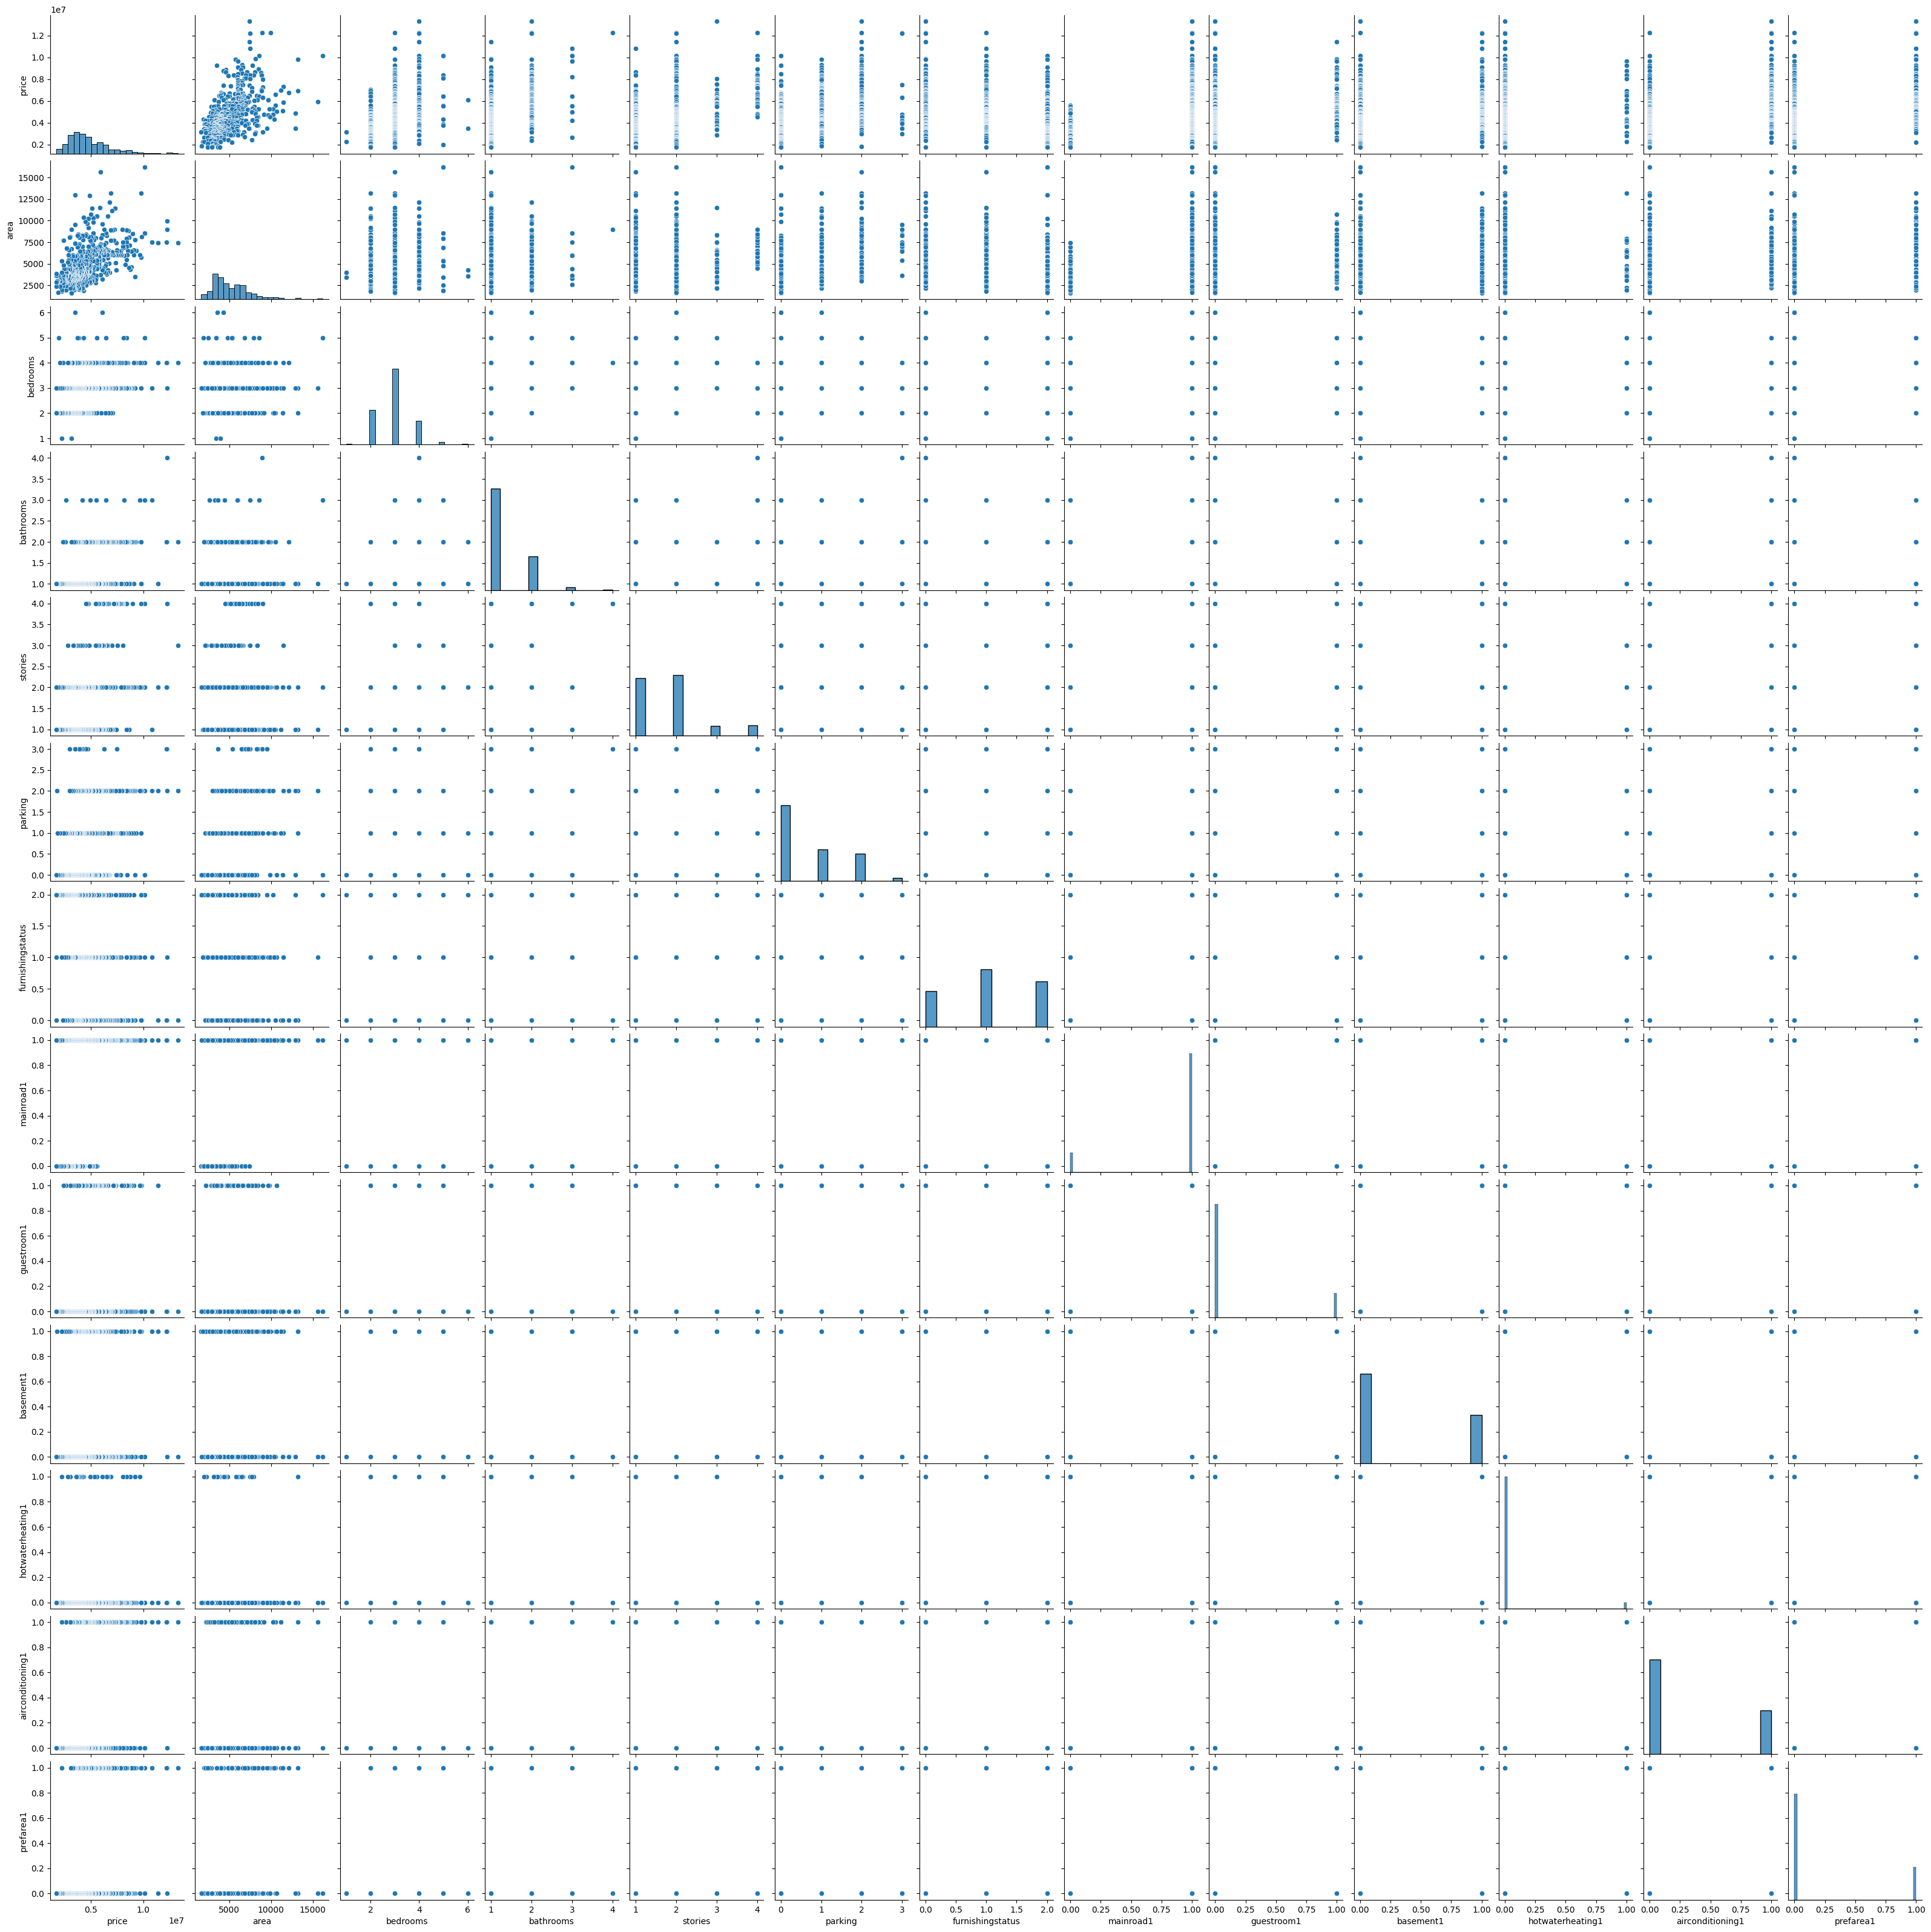

In [183]:
sns.pairplot(data=df)
plt.show()

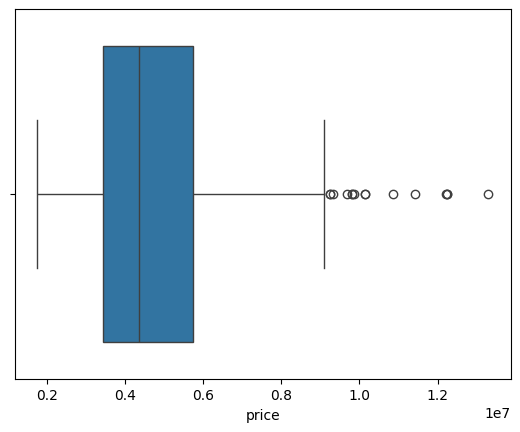

In [184]:
sns.boxplot(x=df["price"],data=df)
plt.show()

In [185]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [186]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus', 'mainroad1', 'guestroom1',
       'basement1', 'hotwaterheating1', 'airconditioning1', 'prefarea1'],
      dtype='object')

In [187]:
x=df[["area","bedrooms","bathrooms","stories","parking","furnishingstatus","mainroad1","guestroom1","basement1","hotwaterheating1","airconditioning1","prefarea1"]]
y=df['price']

In [188]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [189]:
lr=LinearRegression()

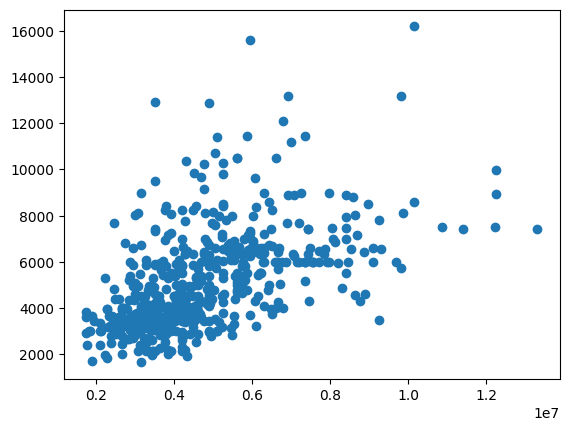

In [190]:
plt.scatter(x=df["price"],y=df["area"])
plt.show()

In [191]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [192]:
lr.score(x_test,y_test),lr.score(x_train,y_train)

(0.6494754192267804, 0.6854429472843788)

In [193]:
x_test

,area,bedrooms,bathrooms,stories,parking,furnishingstatus,mainroad1,guestroom1,basement1,hotwaterheating1,airconditioning1,prefarea1
316,5900,4,2,2,1,2,0,0,1,0,0,0
77,6500,3,2,3,0,0,1,0,0,0,1,1
360,4040,2,1,1,0,1,1,0,0,0,0,0
90,5000,3,1,2,0,1,1,0,0,0,1,0
493,3960,3,1,1,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
15,6000,4,1,2,2,1,1,0,1,0,0,0
357,6930,4,1,2,1,0,0,0,0,0,0,0
39,6000,4,2,4,1,1,1,0,0,0,1,0
54,6000,3,2,2,1,1,1,1,0,0,1,0


In [194]:
lr.predict([[5900,4,2,2,1,2,0,0,1,0,0,0]])

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([5203691.70963178])

In [195]:
y_test

316    4060000
77     6650000
360    3710000
90     6440000
493    2800000
        ...   
15     9100000
357    3773000
39     7910000
54     7350000
155    5530000
Name: price, Length: 109, dtype: int64

In [196]:
from sklearn.tree import DecisionTreeRegressor

In [197]:
for i in range(2,21):
    dc=DecisionTreeRegressor(max_depth=i)
    dc.fit(x_train,y_train)
    print(dc.score(x_test,y_test),dc.score(x_train,y_train))

0.3708112180923593 0.47938063247581686
0.37624793702041404 0.5786983648241125
0.3983209246539525 0.6706658903448168
0.44525179158371364 0.7530624190694271
0.49348592395397917 0.8263167096957358
0.43476871528116956 0.8864912265301349
0.3584870208538701 0.9360090253174943
0.44294401219999624 0.9575463213599172
0.4368599205360161 0.9742668310228508
0.4355300989754032 0.9840899755760157
0.42631875899855265 0.9894862712335322
0.40803608710611616 0.9937614670220454
0.43200198567203185 0.9959409149351157
0.4300295772625282 0.9970803925898202
0.4559156780317958 0.9979124310000118
0.43739549512172304 0.9981126249100082
0.38603759574764673 0.9983099333062054
0.39748370763958685 0.9984947276846636
0.4270934985919258 0.9985402884288594


In [198]:
dc.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [199]:
dc.score(x_test,y_test),dc.score(x_train,y_train)

(0.43921213428740535, 0.9985402884288594)

In [200]:
from sklearn.svm import SVR

In [201]:
sv=SVR(kernel='linear')

In [202]:
sv.fit(x_train,y_train)

,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [203]:
sv.score(x_test,y_test),sv.score(x_train,y_train)

(0.25505202246868275, 0.2766724053502351)

In [204]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(n_neighbors=10)

In [205]:
knn.fit(x_train,y_train)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [206]:
knn.score(x_test,y_test),knn.score(x_train,y_train)

(0.34206502931234295, 0.47496743146941445)

In [207]:
x.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'furnishingstatus', 'mainroad1', 'guestroom1', 'basement1',
       'hotwaterheating1', 'airconditioning1', 'prefarea1'],
      dtype='object')

In [208]:
from sklearn.feature_selection import SequentialFeatureSelector
sf=SequentialFeatureSelector(knn,n_features_to_select=5,direction='forward')

In [209]:
sf.fit(x_train,y_train)

,estimator,KNeighborsReg..._neighbors=10)
,n_features_to_select,5
,tol,None
,direction,'forward'
,scoring,None
,cv,5
,n_jobs,None
,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [210]:
sf.get_support()

array([ True, False,  True, False, False, False,  True,  True, False,
        True, False, False])

In [211]:
from sklearn.model_selection import cross_val_score
knn1=LinearRegression()

In [212]:
score=cross_val_score(knn1,x,y,cv=5)

In [213]:
score

array([ -1.94277003,  -5.00707214, -16.22431367, -21.10749485,
        -5.27173317])

In [214]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus', 'mainroad1', 'guestroom1',
       'basement1', 'hotwaterheating1', 'airconditioning1', 'prefarea1'],
      dtype='object')

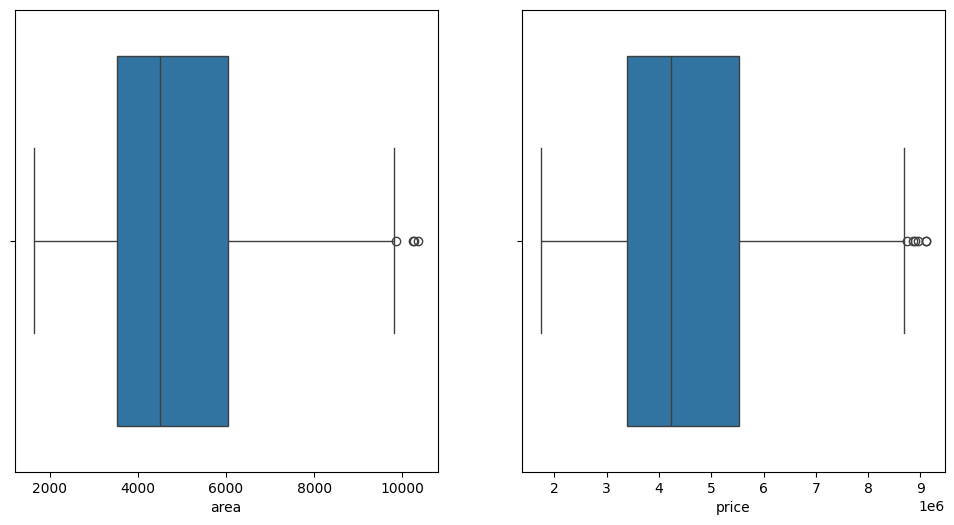

In [225]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.boxplot(x=df["area"],data=df)

plt.subplot(1,2,2)
sns.boxplot(x=df["price"],data=df)
plt.show()

In [216]:
q1=df["area"].quantile(0.25)
q3=df["area"].quantile(0.75)

In [217]:
IQR=q3-q1

In [218]:
min=q1-(IQR*1.5)
max=q3+(IQR*1.5)

In [219]:
q4=df["price"].quantile(0.25)
q5=df["price"].quantile(0.75)

In [220]:
IQR1=q5-q4

In [221]:
min1=q4-(IQR1*1.5)
max1=q5+(IQR1*1.5)

((517, 19), (545, 13))

In [224]:
df=df[(df["price"]<max1)&(df["area"]<max)]

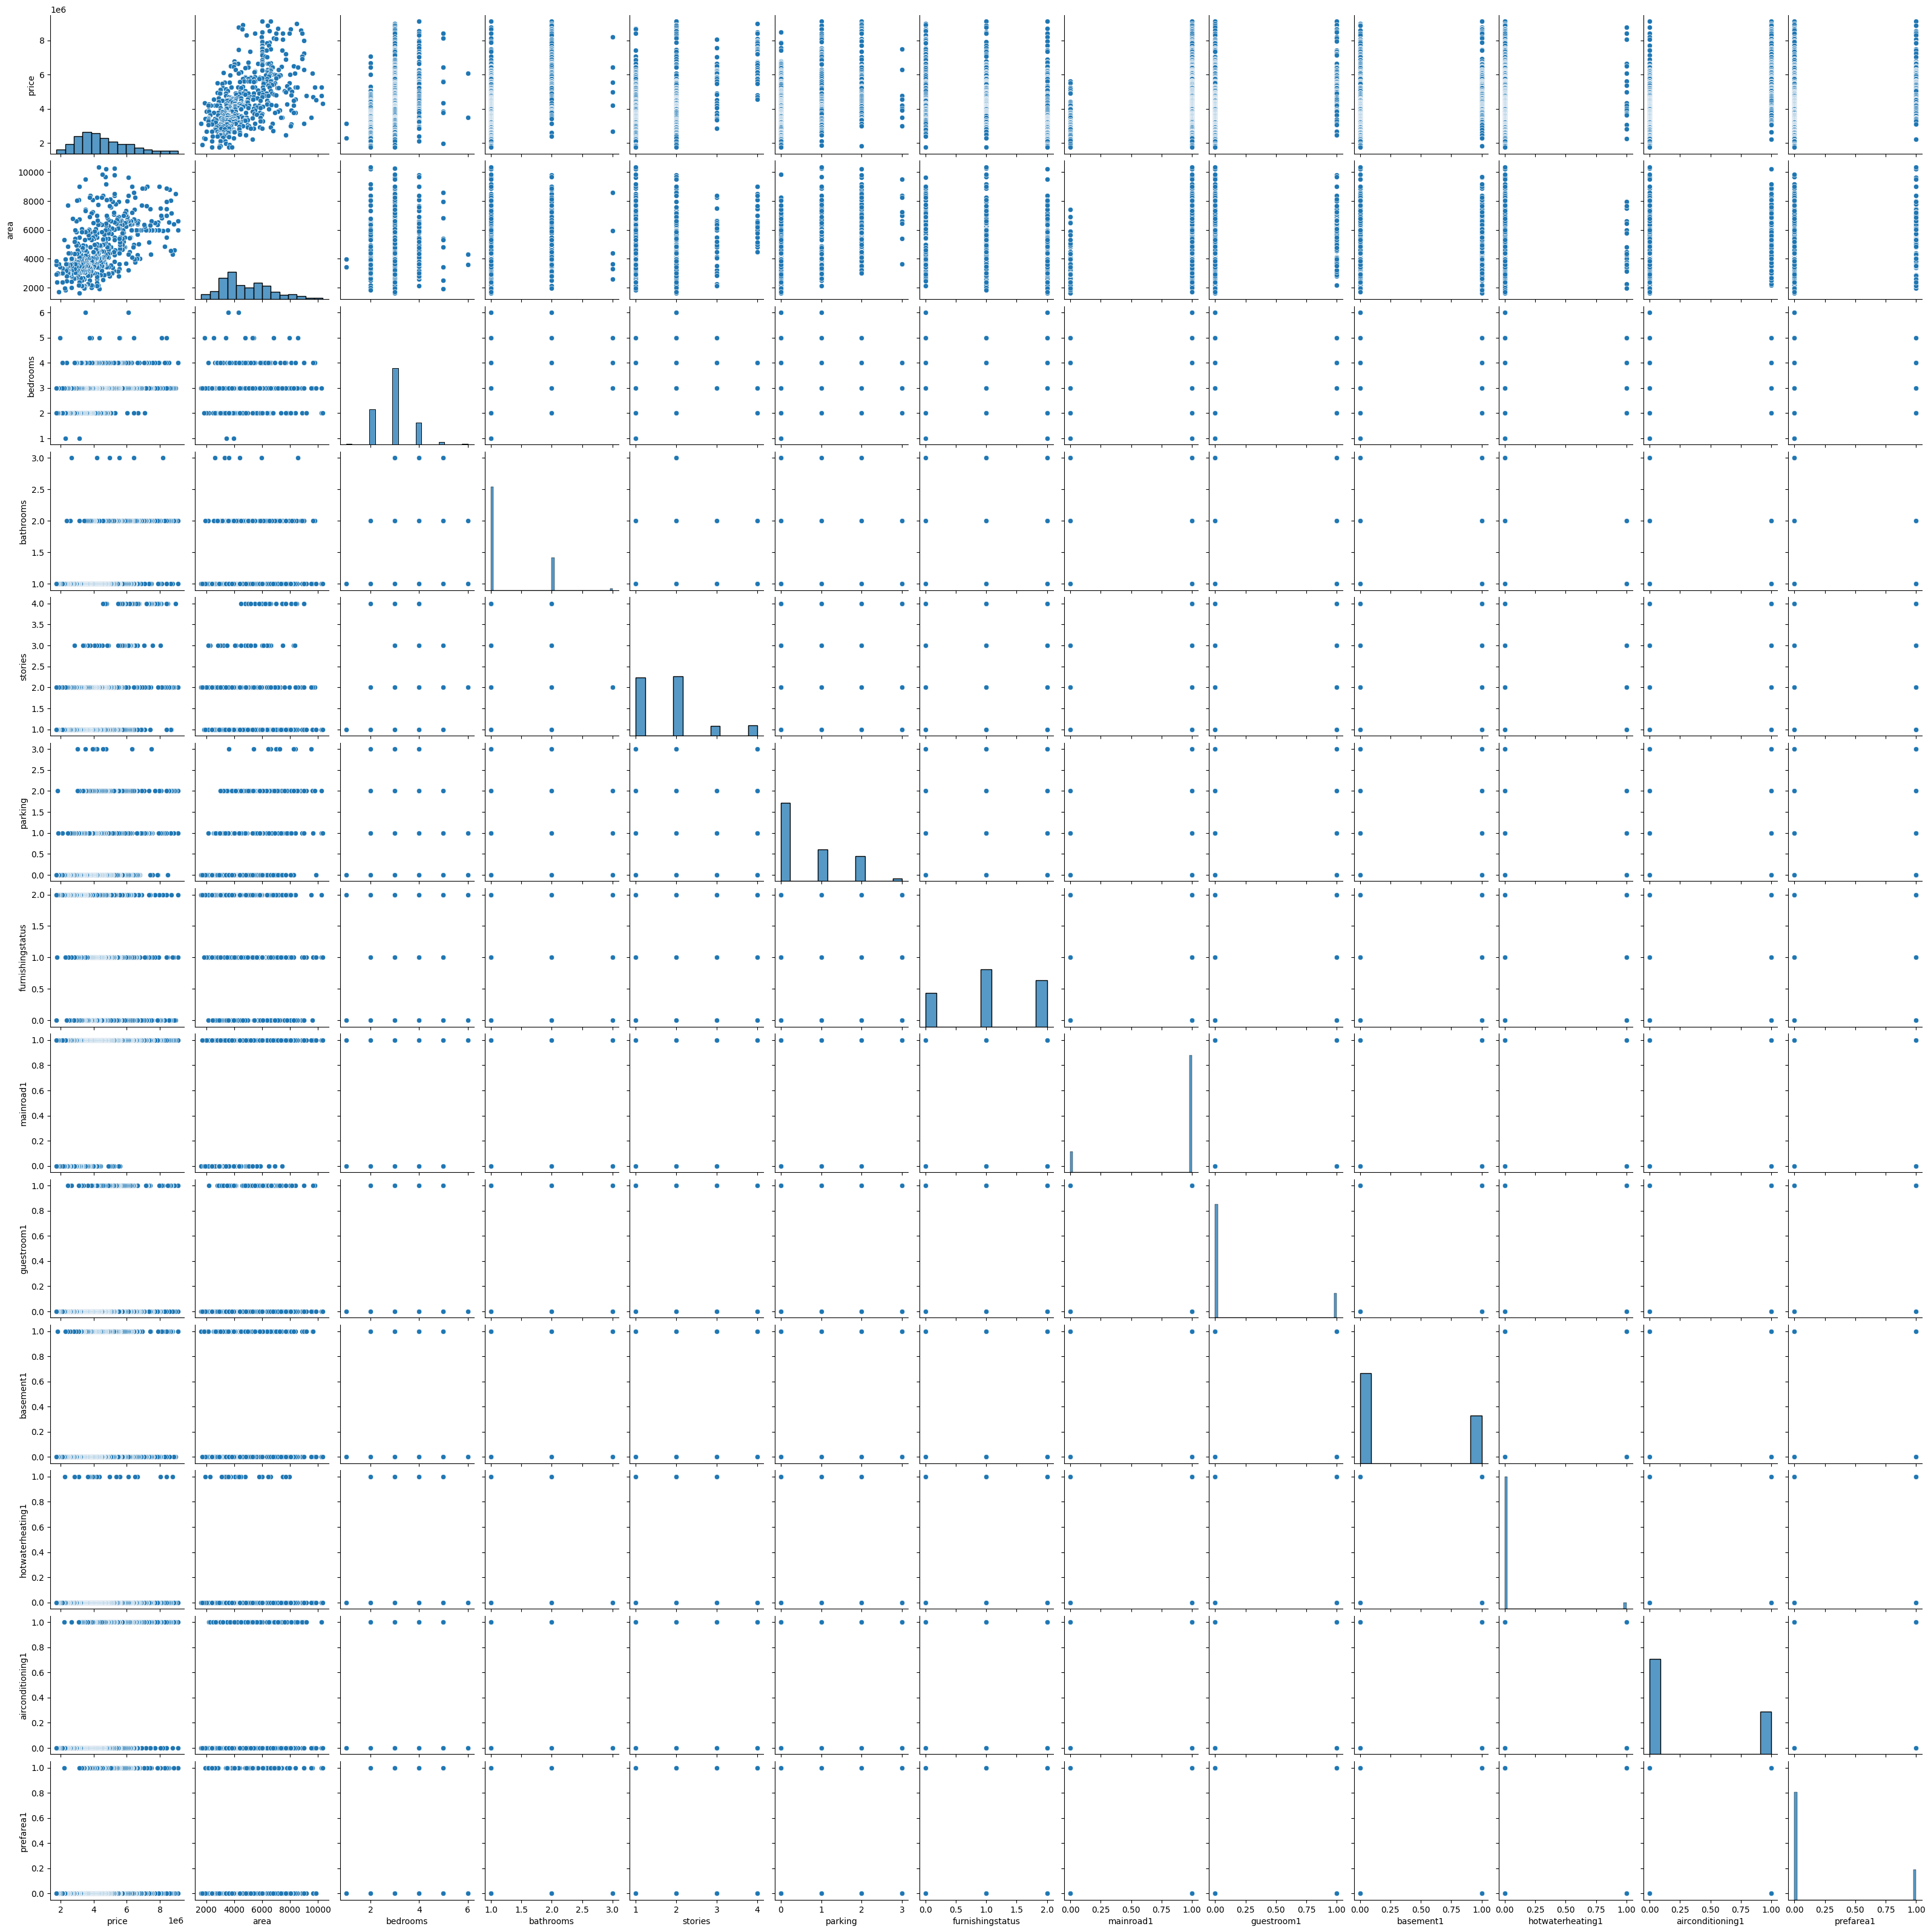

In [228]:
sns.pairplot(data=df)
plt.show()

In [235]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,mainroad1,guestroom1,basement1,hotwaterheating1,airconditioning1,prefarea1,area1
15,9100000,6000,4,1,2,yes,no,yes,no,no,2,no,1,1,0,1,0,0,0,0.624429
16,9100000,6600,4,2,2,yes,yes,yes,no,yes,1,yes,2,1,1,1,0,1,1,0.961991
17,8960000,8500,3,2,4,yes,no,no,no,yes,2,no,0,1,0,0,0,1,0,2.030937
18,8890000,4600,3,2,2,yes,yes,no,no,yes,2,no,0,1,1,0,0,1,0,-0.163216
19,8855000,6420,3,2,2,yes,no,no,no,yes,1,yes,1,1,0,0,0,1,1,0.860722


In [231]:
from sklearn.preprocessing import StandardScaler

In [232]:
sd=StandardScaler()
sd.fit(df[["area"]])

,copy,True
,with_mean,True
,with_std,True


In [234]:
df["area1"]=sd.transform(df[['area']])

In [236]:
X=df[["area","bedrooms","bathrooms","stories","mainroad1","guestroom1","basement1","hotwaterheating1","airconditioning1","parking","prefarea1","furnishingstatus"]]
Y=df["price"]

In [237]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,random_state=42,test_size=0.2)

In [238]:
from sklearn.linear_model import LinearRegression
lr.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [241]:
lr.score(X_test,Y_test),lr.score(X_train,Y_train)

(0.6667603355640939, 0.6565066643134667)

In [247]:
from sklearn.metrics import root_mean_squared_error,r2_score,mean_absolute_error

In [245]:
a=root_mean_squared_error(Y_test,lr.predict(X_test))

In [248]:
root_mean_squared_error(Y_test,lr.predict(X_test)),r2_score(Y_test,lr.predict(X_test)),np.sqrt(a),mean_absolute_error(Y_test,lr.predict(X_test))

(988769.3665784618,
 0.6667603355640939,
 np.float64(994.3688282415443),
 742678.2862974497)

In [258]:
list={"criterion":["squared_error", "friedman_mse", "absolute_error"],"splitter":["best","random"],"max_depth":[i for i in range(2,21)]}

In [259]:
from sklearn.tree import DecisionTreeRegressor
dc=DecisionTreeRegressor()

In [265]:
dc.fit(X_train,Y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [266]:
dc.score(X_test,Y_test)

0.37335494592609375

In [260]:
from sklearn.model_selection import GridSearchCV

In [261]:
gs=GridSearchCV(estimator=DecisionTreeRegressor(),param_grid=list)

In [262]:
gs.fit(X_train,Y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [2, 3, ...], 'splitter': ['best', 'random']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [264]:
gs.best_params_

{'criterion': 'squared_error', 'max_depth': 4, 'splitter': 'best'}

In [267]:
from mlxtend.feature_selection import SequentialFeatureSelector

In [340]:
sf=SequentialFeatureSelector(lr,forward=False,k_features=11)

In [341]:
sf.fit(X_train,Y_train)

,estimator,LinearRegression()
,k_features,"(11, ...)"
,forward,False
,floating,False
,verbose,0
,scoring,'r2'
,cv,5
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


In [342]:
sf.feature_names

['area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad1',
 'guestroom1',
 'basement1',
 'hotwaterheating1',
 'airconditioning1',
 'parking',
 'prefarea1',
 'furnishingstatus']

In [343]:
sf.k_feature_names_

('area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad1',
 'guestroom1',
 'basement1',
 'airconditioning1',
 'parking',
 'prefarea1',
 'furnishingstatus')

In [344]:
sf.k_score_

np.float64(0.5948719108788809)